In [8]:
import dynamax
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
from dynamax.generalized_gaussian_ssm import GeneralizedGaussianSSM

## Plotting state space trajectories for input models

Used gemini to get matplotlib code for creating plot with the line changing color as it goes from start to finish

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_with_gradient_on_curve(x, y, correct_axis=False):

    # 2. Reshape into (num_segments, 2, 2) for LineCollection
    # It needs pairs of (x,y) points for each segment
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1,:,:], points[1:,:,:]], axis=1)

    # 3. Define the gradient values (e.g., based on x-position)
    # This will map values to the colormap
    t = np.linspace(0, 1, len(x))

    # 4. Create LineCollection
    lc = LineCollection(segments, cmap='jet', norm=plt.Normalize(0, 1))
    lc.set_array(t)
    lc.set_linewidth(3)

    ax = plt.gca()
    # 5. Plot the collection
    # fig, ax = plt.subplots()
    ax.add_collection(lc)
    
    if correct_axis:
        ax.set_xlim(x.min() - 0.1, x.max() + 0.1)
        ax.set_ylim(y.min() - 0.1, y.max() + 0.1)

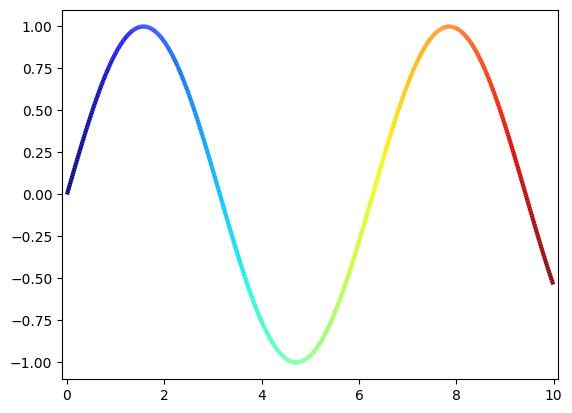

In [45]:
x = np.arange(0, 10, 0.01)
y = np.sin(x)
plot_with_gradient_on_curve(x,y, correct_axis=True)

## Custom code "imports"
was having trouble with relative imports

In [3]:
import numpy as np
import jax.numpy as jnp
from scipy.ndimage import gaussian_filter1d


def _trim_to_bins(arr, bin_ms):
    """Trim the time axis to an integer number of bins.

    Args:
        arr: Array whose last axis is raw time samples.
        bin_ms: Positive integer samples per bin.

    Returns:
        Tuple of trimmed array and number of complete bins.
    """
    n_bins = arr.shape[-1] // bin_ms
    if n_bins < 2:
        raise ValueError(f"trial is too short for {bin_ms} ms bins")
    return arr[..., : n_bins * bin_ms], n_bins


def bin_and_smooth_trials(trials, bin_ms=50, smooth_sigma_bins=1.0, kind="spikes"):
    """Bin and optionally smooth raw trial time series.

    Args:
        trials: Iterable of arrays shaped (n_features, n_time_samples).
        bin_ms: Positive integer samples per output bin.
        smooth_sigma_bins: Gaussian smoothing sigma in output-bin units; 0 disables it.
        kind: "spikes" sums samples within bins; "force" averages samples within bins.

    Returns:
        List of float64 arrays shaped (n_bins, n_features).
    """
    processed = []
    for trial in trials:
        arr = np.asarray(trial, dtype=float)
        trimmed, n_bins = _trim_to_bins(arr, bin_ms)
        if kind == "spikes":
            binned = trimmed.reshape(arr.shape[0], n_bins, bin_ms).sum(axis=2).T
        elif kind == "force":
            binned = trimmed.reshape(arr.shape[0], n_bins, bin_ms).mean(axis=2).T
        else:
            raise ValueError("kind must be 'spikes' or 'force'")
        if smooth_sigma_bins > 0:
            binned = gaussian_filter1d(binned, sigma=smooth_sigma_bins, axis=0, mode="nearest")
        processed.append(binned.astype(np.float64))
    return processed


def split_condition_trials(condition, cond, test_fraction=0.2, seed=7):
    """Split indices for one condition label.

    Args:
        condition: One-dimensional array of condition labels, one per trial.
        cond: Label value to select; must be int-convertible for seeding.
        test_fraction: Fraction of selected trials assigned to test.
        seed: Base RNG seed; cond is added for per-condition reproducibility.

    Returns:
        Sorted train and test index arrays.
    """
    idx = np.flatnonzero(condition == cond)
    rng = np.random.default_rng(seed + int(cond))
    idx = rng.permutation(idx)
    n_test = max(1, int(round(test_fraction * len(idx))))
    return np.sort(idx[n_test:]), np.sort(idx[:n_test])


def pooled_split_indices(condition, test_fraction=0.2, seed=7):
    """Create train/test indices with each condition represented.

    Args:
        condition: One-dimensional array of condition labels, one per trial.
        test_fraction: Fraction of each condition's trials assigned to test.
        seed: Base RNG seed passed to split_condition_trials.

    Returns:
        Sorted train and test index arrays with no overlap.
    """
    train_parts = []
    test_parts = []
    for cond in sorted(np.unique(condition)):
        train_idx, test_idx = split_condition_trials(condition, cond, test_fraction, seed)
        train_parts.append(np.asarray(train_idx, dtype=int))
        test_parts.append(np.asarray(test_idx, dtype=int))
    train_idx = np.sort(np.concatenate(train_parts))
    test_idx = np.sort(np.concatenate(test_parts))
    if np.intersect1d(train_idx, test_idx).size:
        raise ValueError("pooled train/test indices overlap")
    return train_idx, test_idx


def standardize_train_test(train_trials, test_trials, eps=1e-6):
    """Z-score train and test trials using train-set statistics.

    Args:
        train_trials: List of arrays shaped (n_bins_i, n_features).
        test_trials: List of arrays shaped (n_bins_i, n_features).
        eps: Features with train std below eps are scaled by 1.0.

    Returns:
        Standardized train trials, standardized test trials, feature means, and scales.
    """
    stacked = np.concatenate(train_trials, axis=0)
    mean = stacked.mean(axis=0)
    std = stacked.std(axis=0)
    std = np.where(std < eps, 1.0, std)
    train_z = [(x - mean) / std for x in train_trials]
    test_z = [(x - mean) / std for x in test_trials]
    return train_z, test_z, mean, std


def stack_trials(trials):
    """Stack equal-length trials for batched JAX code.

    Args:
        trials: List of arrays with identical shape (n_bins, n_features).

    Returns:
        float64 JAX array shaped (n_trials, n_bins, n_features).
    """
    return jnp.asarray(np.stack(trials), dtype=jnp.float64)


def stack_trials_by_time_length(trials):
    """Group variable-length trials by number of time bins.

    Args:
        trials: List of arrays shaped (n_bins_i, n_features).

    Returns:
        Tuple of float64 JAX arrays shaped (n_trials_g, n_bins_g, n_features),
        ordered by increasing n_bins_g.
    """
    grouped = {}
    for trial in trials:
        arr = np.asarray(trial, dtype=np.float64)
        grouped.setdefault(arr.shape[0], []).append(arr)
    return tuple(jnp.asarray(np.stack(grouped[n_bins]), dtype=jnp.float64) for n_bins in sorted(grouped))


def stack_trial_pairs_by_time_length(y_trials, u_trials):
    """Group paired observation and input trials by shared time length.

    Args:
        y_trials: List of arrays shaped (n_bins_i, n_observation_features).
        u_trials: List of arrays shaped (n_bins_i, n_input_features).

    Returns:
        Tuple of (y_group, u_group) pairs ordered by increasing n_bins. Each
        y_group is shaped (n_trials_g, n_bins_g, n_observation_features), and
        each u_group is shaped (n_trials_g, n_bins_g, n_input_features).
    """
    if len(y_trials) != len(u_trials):
        raise ValueError("y_trials and u_trials must have the same number of trials")
    if len(y_trials) == 0:
        raise ValueError("at least one trial is required")

    observation_dim = y_trials[0].shape[-1]
    input_dim = u_trials[0].shape[-1]
    grouped = {}
    for y, u in zip(y_trials, u_trials):
        y = np.asarray(y, dtype=np.float64)
        u = np.asarray(u, dtype=np.float64)
        if y.ndim != 2 or u.ndim != 2:
            raise ValueError("each y and u trial must be two-dimensional")
        if y.shape[0] != u.shape[0]:
            raise ValueError("paired y and u trials must have the same number of time bins")
        if y.shape[-1] != observation_dim:
            raise ValueError("all y trials must have the same observation dimension")
        if u.shape[-1] != input_dim:
            raise ValueError("all u trials must have the same input dimension")
        grouped.setdefault(y.shape[0], []).append((y, u))

    grouped_pairs = []
    for n_bins in sorted(grouped):
        ys, us = zip(*grouped[n_bins])
        y_group = jnp.asarray(np.stack(ys), dtype=jnp.float64)
        u_group = jnp.asarray(np.stack(us), dtype=jnp.float64)
        grouped_pairs.append((y_group, u_group))
    return tuple(grouped_pairs)


In [4]:
from typing import NamedTuple

import jax
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
from jax.nn import softplus
import numpy as np
import optax
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import EKFIntegrals, ParamsGGSSM
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_smoother as cmgs

RATE_FLOOR = 1e-4
COV_FLOOR = 1e-4


class PoissonLDSParams(NamedTuple):
    """Trainable Poisson LDS parameters in unconstrained optimizer space.

    B is the control-input matrix. For no-input models, B has shape
    (state_dim, 0), and inputs have shape (..., 0).
    """

    A: jnp.ndarray
    B: jnp.ndarray
    C: jnp.ndarray
    d: jnp.ndarray
    log_q: jnp.ndarray
    m0: jnp.ndarray
    log_s0: jnp.ndarray


def inverse_softplus(x):
    """Map positive values to unconstrained softplus inputs."""
    return jnp.log(jnp.expm1(jnp.maximum(jnp.asarray(x), 1e-6)))


def positive_diag(log_diag):
    """Convert unconstrained covariance diagonal parameters to positive values."""
    return softplus(log_diag) + COV_FLOOR


def _as_stacked_counts(y_train):
    """Convert stacked spike-count trials to a float64 JAX array."""
    y_train = jnp.asarray(y_train, dtype=jnp.float64)
    if y_train.ndim != 3:
        raise ValueError("y_train must have shape (n_trials, n_bins, n_neurons)")
    return y_train


def _as_stacked_inputs(y_train, u_train=None):
    """Return inputs shaped (n_trials, n_bins, input_dim), using input_dim 0 by default."""
    if u_train is None:
        return jnp.zeros(y_train.shape[:2] + (0,), dtype=y_train.dtype)
    u_train = jnp.asarray(u_train, dtype=jnp.float64)
    if u_train.ndim != 3:
        raise ValueError("u_train must have shape (n_trials, n_bins, input_dim)")
    if y_train.shape[:2] != u_train.shape[:2]:
        raise ValueError("y_train and u_train must have matching trial and time dimensions")
    return u_train


def _as_trial_list(trials, name):
    """Convert a trial sequence to a nonempty list of float64 NumPy arrays."""
    trials = [np.asarray(trial, dtype=np.float64) for trial in trials]
    if len(trials) == 0:
        raise ValueError(f"{name} must contain at least one trial")
    if any(trial.ndim != 2 for trial in trials):
        raise ValueError(f"each {name} trial must be two-dimensional")
    return trials


def _as_input_trial_list(y_trials, u_trials=None):
    """Return input trials aligned to y_trials, using input_dim 0 by default."""
    if u_trials is None:
        return [np.zeros((y.shape[0], 0), dtype=np.float64) for y in y_trials]
    return _as_trial_list(u_trials, "u_trials")


def poisson_rate(trainable_params, z):
    """Compute positive Poisson rates for one latent state."""
    return softplus(trainable_params.C @ z + trainable_params.d) + RATE_FLOOR


def make_poisson_lds_params(trainable_params):
    """Build Dynamax GGSSM parameters for a Poisson LDS with unified inputs.

    The returned functions expect inputs. For no-input models, pass zero-width
    inputs shaped (n_bins, 0).
    """
    rate = lambda z: poisson_rate(trainable_params, z)
    return ParamsGGSSM(
        initial_mean=trainable_params.m0,
        initial_covariance=jnp.diag(positive_diag(trainable_params.log_s0)),
        dynamics_function=lambda z, u: trainable_params.A @ z + trainable_params.B @ u,
        dynamics_covariance=jnp.diag(positive_diag(trainable_params.log_q)),
        emission_mean_function=lambda z, u: rate(z),
        emission_cov_function=lambda z, u: jnp.diag(rate(z)),
        emission_dist=lambda mu, Sigma: Poisson(rate=mu),
    )


def initialize_trainable_params(y_train, state_dim, key, u_train=None):
    """Initialize trainable parameters from equal-length spike-count trials."""
    y_train = _as_stacked_counts(y_train)
    u_train = _as_stacked_inputs(y_train, u_train)
    emission_dim = y_train.shape[-1]
    input_dim = u_train.shape[-1]
    mean_counts = jnp.mean(y_train, axis=(0, 1))
    baseline_rate = jnp.maximum(mean_counts - RATE_FLOOR, 1e-3)
    return PoissonLDSParams(
        A=0.95 * jnp.eye(state_dim),
        B=jnp.zeros((state_dim, input_dim)),
        C=0.01 * jr.normal(key, (emission_dim, state_dim)),
        d=inverse_softplus(baseline_rate),
        log_q=inverse_softplus(0.1 * jnp.ones(state_dim)),
        m0=jnp.zeros(state_dim),
        log_s0=inverse_softplus(jnp.ones(state_dim)),
    )


def initialize_trainable_params_from_trials(y_trials, state_dim, key, u_trials=None):
    """Initialize trainable parameters from variable-length spike-count trials."""
    y_trials = _as_trial_list(y_trials, "y_trials")
    u_trials = _as_input_trial_list(y_trials, u_trials)
    stack_trial_pairs_by_time_length(y_trials, u_trials)
    emission_dim = y_trials[0].shape[-1]
    input_dim = u_trials[0].shape[-1]
    mean_counts = jnp.asarray(np.concatenate(y_trials, axis=0).mean(axis=0), dtype=jnp.float64)
    baseline_rate = jnp.maximum(mean_counts - RATE_FLOOR, 1e-3)
    return PoissonLDSParams(
        A=0.95 * jnp.eye(state_dim),
        B=jnp.zeros((state_dim, input_dim)),
        C=0.01 * jr.normal(key, (emission_dim, state_dim)),
        d=inverse_softplus(baseline_rate),
        log_q=inverse_softplus(0.1 * jnp.ones(state_dim)),
        m0=jnp.zeros(state_dim),
        log_s0=inverse_softplus(jnp.ones(state_dim)),
    )


def poisson_lds_loss(trainable_params, y_train, u_train):
    """Compute negative marginal log likelihood per bin for stacked trials."""
    params = make_poisson_lds_params(trainable_params)
    posts = vmap(lambda y, u: cmgs(params, EKFIntegrals(), y, inputs=u))(y_train, u_train)
    return -jnp.mean(posts.marginal_loglik) / y_train.shape[1]


def poisson_lds_grouped_loss(trainable_params, grouped_yu_train):
    """Compute negative marginal log likelihood per bin for grouped trials."""
    params = make_poisson_lds_params(trainable_params)
    total_loglik = 0.0
    total_bins = 0
    for y_group, u_group in grouped_yu_train:
        posts = vmap(lambda y, u: cmgs(params, EKFIntegrals(), y, inputs=u))(y_group, u_group)
        total_loglik = total_loglik + jnp.sum(posts.marginal_loglik)
        total_bins += y_group.shape[0] * y_group.shape[1]
    return -total_loglik / total_bins


def _run_adam_learning(
    trainable_params,
    loss_fn,
    loss_args,
    make_params_fn,
    learning_steps,
    learning_rate,
    trace_scale,
    verbose=False,
    log_prefix="step",
):
    """Run the shared Adam loop for Poisson LDS learning."""
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(trainable_params)

    @jax.jit
    def step(trainable_params, opt_state):
        loss, grads = jax.value_and_grad(loss_fn)(trainable_params, *loss_args)
        updates, opt_state = optimizer.update(grads, opt_state, trainable_params)
        trainable_params = optax.apply_updates(trainable_params, updates)
        return trainable_params, opt_state, loss

    losses = []
    for i in range(learning_steps):
        trainable_params, opt_state, loss = step(trainable_params, opt_state)
        loss_value = float(loss)
        if not np.isfinite(loss_value):
            raise FloatingPointError(f"non-finite Poisson LDS loss at step {i + 1}: {loss_value}")
        losses.append(loss_value)
        if verbose and (i == 0 or (i + 1) % 10 == 0 or i + 1 == learning_steps):
            print(f"{log_prefix} {i + 1:03d}: neg loglik/bin={loss_value:.3f}")

    likelihood_trace = -np.asarray(losses) * trace_scale
    return trainable_params, make_params_fn(trainable_params), likelihood_trace


def learn_poisson_lds(
    y_train,
    state_dim,
    key,
    u_train=None,
    learning_steps=100,
    learning_rate=1e-2,
    verbose=False,
):
    """Fit a Poisson LDS to equal-length trials, optionally conditioned on inputs.

    Args:
        y_train: Count array shaped (n_trials, n_bins, n_neurons).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used for parameter initialization.
        u_train: Optional input array shaped (n_trials, n_bins, input_dim). If
            omitted, a no-input model is represented with input_dim 0.
        learning_steps: Number of Adam updates.
        learning_rate: Adam step size.
        verbose: If True, print periodic loss values.

    Returns:
        Tuple of trainable params, Dynamax params, and marginal log-likelihood trace.
    """
    y_train = _as_stacked_counts(y_train)
    u_train = _as_stacked_inputs(y_train, u_train)
    trainable_params = initialize_trainable_params(y_train, state_dim, key, u_train=u_train)
    return _run_adam_learning(
        trainable_params,
        poisson_lds_loss,
        (y_train, u_train),
        make_poisson_lds_params,
        learning_steps,
        learning_rate,
        trace_scale=y_train.shape[1],
        verbose=verbose,
        log_prefix="poisson",
    )


def learn_poisson_lds_grouped(
    y_train,
    state_dim,
    key,
    u_train=None,
    learning_steps=100,
    learning_rate=1e-2,
    verbose=False,
):
    """Fit a Poisson LDS to variable-length trials, optionally conditioned on inputs."""
    y_train = _as_trial_list(y_train, "y_train")
    u_train = _as_input_trial_list(y_train, u_train)
    grouped_yu_train = stack_trial_pairs_by_time_length(y_train, u_train)
    trainable_params = initialize_trainable_params_from_trials(y_train, state_dim, key, u_trials=u_train)
    return _run_adam_learning(
        trainable_params,
        poisson_lds_grouped_loss,
        (grouped_yu_train,),
        make_poisson_lds_params,
        learning_steps,
        learning_rate,
        trace_scale=1.0,
        verbose=verbose,
        log_prefix="pooled poisson",
    )


def infer_latents(params, trials, u_trials=None):
    """Infer smoothed latent means for each trial, optionally conditioned on inputs."""
    trials = _as_trial_list(trials, "trials")
    u_trials = _as_input_trial_list(trials, u_trials)
    stack_trial_pairs_by_time_length(trials, u_trials)
    return [
        np.asarray(cmgs(params, EKFIntegrals(), jnp.asarray(y), inputs=jnp.asarray(u)).smoothed_means)
        for y, u in zip(trials, u_trials)
    ]


def infer_latents_grouped(params, trials, u_trials=None):
    """Infer latents for variable-length trials while preserving input order."""
    trials = _as_trial_list(trials, "trials")
    u_trials = _as_input_trial_list(trials, u_trials)
    groups = {}
    for i, (y, u) in enumerate(zip(trials, u_trials)):
        groups.setdefault(y.shape[0], []).append((i, y, u))

    latents = [None] * len(trials)
    for n_bins in sorted(groups):
        indices, ys, us = zip(*groups[n_bins])
        y_stack = jnp.asarray(np.stack(ys), dtype=jnp.float64)
        u_stack = jnp.asarray(np.stack(us), dtype=jnp.float64)
        posts = vmap(lambda y, u: cmgs(params, EKFIntegrals(), y, inputs=u))(y_stack, u_stack)
        z_stack = np.asarray(posts.smoothed_means)
        for local_i, trial_i in enumerate(indices):
            latents[trial_i] = z_stack[local_i]
    return latents


def predict_expected_counts(params, trainable_params, trials, u_trials=None):
    """Predict expected counts from smoothed latent states."""
    latents = infer_latents(params, trials, u_trials=u_trials)
    expected_counts = [np.asarray(vmap(lambda z: poisson_rate(trainable_params, z))(jnp.asarray(z))) for z in latents]
    for expected, y in zip(expected_counts, trials):
        if expected.shape != y.shape or not np.all(np.isfinite(expected)) or np.any(expected < 0):
            raise FloatingPointError(f"invalid Poisson expected count with shape {expected.shape}; expected {y.shape}")
    return expected_counts


def marginal_log_prob_per_bin(params, trials, u_trials=None):
    """Average marginal log probability per time bin across trials."""
    trials = _as_trial_list(trials, "trials")
    u_trials = _as_input_trial_list(trials, u_trials)
    vals = [
        float(cmgs(params, EKFIntegrals(), jnp.asarray(y), inputs=jnp.asarray(u)).marginal_loglik) / y.shape[0]
        for y, u in zip(trials, u_trials)
    ]
    return float(np.mean(vals))


In [5]:
import numpy as np
import jax.numpy as jnp
from scipy.ndimage import gaussian_filter1d


def _trim_to_bins(arr, bin_ms):
    """Trim the time axis to an integer number of bins.

    Args:
        arr: Array whose last axis is raw time samples.
        bin_ms: Positive integer samples per bin.

    Returns:
        Tuple of trimmed array and number of complete bins.
    """
    n_bins = arr.shape[-1] // bin_ms
    if n_bins < 2:
        raise ValueError(f"trial is too short for {bin_ms} ms bins")
    return arr[..., : n_bins * bin_ms], n_bins


def bin_and_smooth_trials(trials, bin_ms=50, smooth_sigma_bins=1.0, kind="spikes"):
    """Bin and optionally smooth raw trial time series.

    Args:
        trials: Iterable of arrays shaped (n_features, n_time_samples).
        bin_ms: Positive integer samples per output bin.
        smooth_sigma_bins: Gaussian smoothing sigma in output-bin units; 0 disables it.
        kind: "spikes" sums samples within bins; "force" averages samples within bins.

    Returns:
        List of float64 arrays shaped (n_bins, n_features).
    """
    processed = []
    for trial in trials:
        arr = np.asarray(trial, dtype=float)
        trimmed, n_bins = _trim_to_bins(arr, bin_ms)
        if kind == "spikes":
            binned = trimmed.reshape(arr.shape[0], n_bins, bin_ms).sum(axis=2).T
        elif kind == "force":
            binned = trimmed.reshape(arr.shape[0], n_bins, bin_ms).mean(axis=2).T
        else:
            raise ValueError("kind must be 'spikes' or 'force'")
        if smooth_sigma_bins > 0:
            binned = gaussian_filter1d(binned, sigma=smooth_sigma_bins, axis=0, mode="nearest")
        processed.append(binned.astype(np.float64))
    return processed


def split_condition_trials(condition, cond, test_fraction=0.2, seed=7):
    """Split indices for one condition label.

    Args:
        condition: One-dimensional array of condition labels, one per trial.
        cond: Label value to select; must be int-convertible for seeding.
        test_fraction: Fraction of selected trials assigned to test.
        seed: Base RNG seed; cond is added for per-condition reproducibility.

    Returns:
        Sorted train and test index arrays.
    """
    idx = np.flatnonzero(condition == cond)
    rng = np.random.default_rng(seed + int(cond))
    idx = rng.permutation(idx)
    n_test = max(1, int(round(test_fraction * len(idx))))
    return np.sort(idx[n_test:]), np.sort(idx[:n_test])


def pooled_split_indices(condition, test_fraction=0.2, seed=7):
    """Create train/test indices with each condition represented.

    Args:
        condition: One-dimensional array of condition labels, one per trial.
        test_fraction: Fraction of each condition's trials assigned to test.
        seed: Base RNG seed passed to split_condition_trials.

    Returns:
        Sorted train and test index arrays with no overlap.
    """
    train_parts = []
    test_parts = []
    for cond in sorted(np.unique(condition)):
        train_idx, test_idx = split_condition_trials(condition, cond, test_fraction, seed)
        train_parts.append(np.asarray(train_idx, dtype=int))
        test_parts.append(np.asarray(test_idx, dtype=int))
    train_idx = np.sort(np.concatenate(train_parts))
    test_idx = np.sort(np.concatenate(test_parts))
    if np.intersect1d(train_idx, test_idx).size:
        raise ValueError("pooled train/test indices overlap")
    return train_idx, test_idx


def standardize_train_test(train_trials, test_trials, eps=1e-6):
    """Z-score train and test trials using train-set statistics.

    Args:
        train_trials: List of arrays shaped (n_bins_i, n_features).
        test_trials: List of arrays shaped (n_bins_i, n_features).
        eps: Features with train std below eps are scaled by 1.0.

    Returns:
        Standardized train trials, standardized test trials, feature means, and scales.
    """
    stacked = np.concatenate(train_trials, axis=0)
    mean = stacked.mean(axis=0)
    std = stacked.std(axis=0)
    std = np.where(std < eps, 1.0, std)
    train_z = [(x - mean) / std for x in train_trials]
    test_z = [(x - mean) / std for x in test_trials]
    return train_z, test_z, mean, std


def stack_trials(trials):
    """Stack equal-length trials for batched JAX code.

    Args:
        trials: List of arrays with identical shape (n_bins, n_features).

    Returns:
        float64 JAX array shaped (n_trials, n_bins, n_features).
    """
    return jnp.asarray(np.stack(trials), dtype=jnp.float64)


def stack_trials_by_time_length(trials):
    """Group variable-length trials by number of time bins.

    Args:
        trials: List of arrays shaped (n_bins_i, n_features).

    Returns:
        Tuple of float64 JAX arrays shaped (n_trials_g, n_bins_g, n_features),
        ordered by increasing n_bins_g.
    """
    grouped = {}
    for trial in trials:
        arr = np.asarray(trial, dtype=np.float64)
        grouped.setdefault(arr.shape[0], []).append(arr)
    return tuple(jnp.asarray(np.stack(grouped[n_bins]), dtype=jnp.float64) for n_bins in sorted(grouped))


def stack_trial_pairs_by_time_length(y_trials, u_trials):
    """Group paired observation and input trials by shared time length.

    Args:
        y_trials: List of arrays shaped (n_bins_i, n_observation_features).
        u_trials: List of arrays shaped (n_bins_i, n_input_features).

    Returns:
        Tuple of (y_group, u_group) pairs ordered by increasing n_bins. Each
        y_group is shaped (n_trials_g, n_bins_g, n_observation_features), and
        each u_group is shaped (n_trials_g, n_bins_g, n_input_features).
    """
    if len(y_trials) != len(u_trials):
        raise ValueError("y_trials and u_trials must have the same number of trials")
    if len(y_trials) == 0:
        raise ValueError("at least one trial is required")

    observation_dim = y_trials[0].shape[-1]
    input_dim = u_trials[0].shape[-1]
    grouped = {}
    for y, u in zip(y_trials, u_trials):
        y = np.asarray(y, dtype=np.float64)
        u = np.asarray(u, dtype=np.float64)
        if y.ndim != 2 or u.ndim != 2:
            raise ValueError("each y and u trial must be two-dimensional")
        if y.shape[0] != u.shape[0]:
            raise ValueError("paired y and u trials must have the same number of time bins")
        if y.shape[-1] != observation_dim:
            raise ValueError("all y trials must have the same observation dimension")
        if u.shape[-1] != input_dim:
            raise ValueError("all u trials must have the same input dimension")
        grouped.setdefault(y.shape[0], []).append((y, u))

    grouped_pairs = []
    for n_bins in sorted(grouped):
        ys, us = zip(*grouped[n_bins])
        y_group = jnp.asarray(np.stack(ys), dtype=jnp.float64)
        u_group = jnp.asarray(np.stack(us), dtype=jnp.float64)
        grouped_pairs.append((y_group, u_group))
    return tuple(grouped_pairs)


In [6]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
from jax.nn import softplus
import optax
import numpy as np
from typing import NamedTuple
from tensorflow_probability.substrates.jax.distributions import Poisson
from dynamax.generalized_gaussian_ssm import ParamsGGSSM, EKFIntegrals
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_smoother as cmgs
# from .preprocessing import stack_trial_pairs_by_time_length, stack_trials_by_time_length

RATE_FLOOR = 1e-4
COV_FLOOR = 1e-4


class PoissonLDSParams(NamedTuple):
    """Trainable Poisson LDS parameters stored in unconstrained optimizer space."""
    A: jnp.ndarray
    C: jnp.ndarray
    d: jnp.ndarray
    log_q: jnp.ndarray
    m0: jnp.ndarray
    log_s0: jnp.ndarray


class PoissonLDSInputParams(NamedTuple):
    """Trainable controlled Poisson LDS parameters stored in unconstrained optimizer space.

    This input-driven variant adds B shaped (state_dim, input_dim). The covariance
    diagonal fields log_q and log_s0 remain unconstrained optimizer parameters.
    """
    A: jnp.ndarray
    B: jnp.ndarray
    C: jnp.ndarray
    d: jnp.ndarray
    log_q: jnp.ndarray
    m0: jnp.ndarray
    log_s0: jnp.ndarray


def inverse_softplus(x):
    """Map positive values to unconstrained softplus inputs.

    Args:
        x: Positive scalar or array of positive values.

    Returns:
        Array with the same shape as x in unconstrained space.
    """
    return jnp.log(jnp.expm1(jnp.maximum(jnp.asarray(x), 1e-6)))


def positive_diag(log_diag):
    """Convert unconstrained covariance diagonal parameters.

    Args:
        log_diag: Vector of unconstrained diagonal covariance parameters.

    Returns:
        Positive covariance diagonal vector with the same shape.
    """
    return softplus(log_diag) + COV_FLOOR


def poisson_rate(trainable_params, z):
    """Compute emission rates for one latent state.

    Args:
        trainable_params: PoissonLDSParams with C shaped (n_neurons, state_dim)
            and d shaped (n_neurons,).
        z: Latent state vector shaped (state_dim,).

    Returns:
        Positive Poisson rates shaped (n_neurons,).
    """
    return softplus(trainable_params.C @ z + trainable_params.d) + RATE_FLOOR


def make_poisson_lds_params(trainable_params):
    """Build Dynamax GGSSM parameters from unconstrained trainable arrays.

    Args:
        trainable_params: PoissonLDSParams containing A (state_dim, state_dim),
            C (n_neurons, state_dim), d (n_neurons,), log_q (state_dim,),
            m0 (state_dim,), and log_s0 (state_dim,).

    Returns:
        ParamsGGSSM with diagonal initial/dynamics covariances and Poisson emissions.
    """
    rate = lambda z: poisson_rate(trainable_params, z)
    return ParamsGGSSM(
        initial_mean=trainable_params.m0,
        initial_covariance=jnp.diag(positive_diag(trainable_params.log_s0)),
        dynamics_function=lambda z: trainable_params.A @ z,
        dynamics_covariance=jnp.diag(positive_diag(trainable_params.log_q)),
        emission_mean_function=rate,
        emission_cov_function=lambda z: jnp.diag(rate(z)),
        emission_dist=lambda mu, Sigma: Poisson(rate=mu),
    )


def make_poisson_lds_input_params(trainable_params):
    """Build Dynamax GGSSM parameters for a controlled Poisson LDS.

    Args:
        trainable_params: PoissonLDSInputParams containing A (state_dim, state_dim),
            B (state_dim, input_dim), C (n_neurons, state_dim), d (n_neurons,),
            log_q (state_dim,), m0 (state_dim,), and log_s0 (state_dim,).

    Returns:
        ParamsGGSSM whose dynamics and emission moment functions accept inputs.
    """
    rate = lambda z: poisson_rate(trainable_params, z)
    return ParamsGGSSM(
        initial_mean=trainable_params.m0,
        initial_covariance=jnp.diag(positive_diag(trainable_params.log_s0)),
        dynamics_function=lambda z, u: trainable_params.A @ z + trainable_params.B @ u,
        dynamics_covariance=jnp.diag(positive_diag(trainable_params.log_q)),
        emission_mean_function=lambda z, u: rate(z),
        emission_cov_function=lambda z, u: jnp.diag(rate(z)),
        emission_dist=lambda mu, Sigma: Poisson(rate=mu),
    )


def initialize_trainable_params(y_train, state_dim, key):
    """Initialize trainable parameters from equal-length spike-count trials.

    Args:
        y_train: Count array shaped (n_trials, n_bins, n_neurons).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used to initialize C.

    Returns:
        PoissonLDSParams in unconstrained optimizer space.
    """
    emission_dim = y_train.shape[-1]
    mean_counts = jnp.mean(y_train, axis=(0, 1))
    baseline_rate = jnp.maximum(mean_counts - RATE_FLOOR, 1e-3)
    return PoissonLDSParams(
        A=0.95 * jnp.eye(state_dim),
        C=0.01 * jr.normal(key, (emission_dim, state_dim)),
        d=inverse_softplus(baseline_rate),
        log_q=inverse_softplus(0.1 * jnp.ones(state_dim)),
        m0=jnp.zeros(state_dim),
        log_s0=inverse_softplus(jnp.ones(state_dim)),
    )


def initialize_trainable_params_from_trials(y_trials, state_dim, key):
    """Initialize trainable parameters from variable-length spike-count trials.

    Args:
        y_trials: Nonempty list of arrays, each shaped (n_bins_i, n_neurons);
            all trials must have the same neuron count.
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used to initialize C.

    Returns:
        PoissonLDSParams in unconstrained optimizer space.
    """
    emission_dim = y_trials[0].shape[-1]
    if any(y.shape[-1] != emission_dim for y in y_trials):
        raise ValueError("all trials must have the same number of neurons")
    mean_counts = jnp.asarray(np.concatenate(y_trials, axis=0).mean(axis=0), dtype=jnp.float64)
    baseline_rate = jnp.maximum(mean_counts - RATE_FLOOR, 1e-3)
    return PoissonLDSParams(
        A=0.95 * jnp.eye(state_dim),
        C=0.01 * jr.normal(key, (emission_dim, state_dim)),
        d=inverse_softplus(baseline_rate),
        log_q=inverse_softplus(0.1 * jnp.ones(state_dim)),
        m0=jnp.zeros(state_dim),
        log_s0=inverse_softplus(jnp.ones(state_dim)),
    )


def initialize_trainable_input_params(y_train, u_train, state_dim, key):
    """Initialize controlled Poisson LDS parameters from equal-length trials.

    Args:
        y_train: Count array shaped (n_trials, n_bins, n_neurons).
        u_train: Input array shaped (n_trials, n_bins, input_dim).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used to initialize C.

    Returns:
        PoissonLDSInputParams in unconstrained optimizer space.
    """
    if y_train.shape[:2] != u_train.shape[:2]:
        raise ValueError("y_train and u_train must have matching trial and time dimensions")
    emission_dim = y_train.shape[-1]
    input_dim = u_train.shape[-1]
    mean_counts = jnp.mean(y_train, axis=(0, 1))
    baseline_rate = jnp.maximum(mean_counts - RATE_FLOOR, 1e-3)
    return PoissonLDSInputParams(
        A=0.95 * jnp.eye(state_dim),
        B=jnp.zeros((state_dim, input_dim)),
        C=0.01 * jr.normal(key, (emission_dim, state_dim)),
        d=inverse_softplus(baseline_rate),
        log_q=inverse_softplus(0.1 * jnp.ones(state_dim)),
        m0=jnp.zeros(state_dim),
        log_s0=inverse_softplus(jnp.ones(state_dim)),
    )


def initialize_trainable_input_params_from_trials(y_trials, u_trials, state_dim, key):
    """Initialize controlled Poisson LDS parameters from variable-length trials.

    Args:
        y_trials: Nonempty list of arrays, each shaped (n_bins_i, n_neurons).
        u_trials: Nonempty list of arrays, each shaped (n_bins_i, input_dim).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used to initialize C.

    Returns:
        PoissonLDSInputParams in unconstrained optimizer space.
    """
    stack_trial_pairs_by_time_length(y_trials, u_trials)
    emission_dim = y_trials[0].shape[-1]
    input_dim = u_trials[0].shape[-1]
    mean_counts = jnp.asarray(np.concatenate(y_trials, axis=0).mean(axis=0), dtype=jnp.float64)
    baseline_rate = jnp.maximum(mean_counts - RATE_FLOOR, 1e-3)
    return PoissonLDSInputParams(
        A=0.95 * jnp.eye(state_dim),
        B=jnp.zeros((state_dim, input_dim)),
        C=0.01 * jr.normal(key, (emission_dim, state_dim)),
        d=inverse_softplus(baseline_rate),
        log_q=inverse_softplus(0.1 * jnp.ones(state_dim)),
        m0=jnp.zeros(state_dim),
        log_s0=inverse_softplus(jnp.ones(state_dim)),
    )


def poisson_lds_loss(trainable_params, y_train):
    """Compute negative marginal log likelihood per bin for stacked trials.

    Args:
        trainable_params: PoissonLDSParams to score.
        y_train: Count array shaped (n_trials, n_bins, n_neurons).

    Returns:
        Scalar JAX loss averaged over trials and time bins.
    """
    params = make_poisson_lds_params(trainable_params)
    posts = vmap(lambda y: cmgs(params, EKFIntegrals(), y))(y_train)
    return -jnp.mean(posts.marginal_loglik) / y_train.shape[1]


def poisson_lds_grouped_loss(trainable_params, grouped_y_train):
    """Compute negative marginal log likelihood per bin for grouped trials.

    Args:
        trainable_params: PoissonLDSParams to score.
        grouped_y_train: Tuple of arrays shaped (n_trials_g, n_bins_g, n_neurons),
            one group per shared trial length.

    Returns:
        Scalar JAX loss averaged over all trials and time bins.
    """
    params = make_poisson_lds_params(trainable_params)
    total_loglik = 0.0
    total_bins = 0
    for y_group in grouped_y_train:
        posts = vmap(lambda y: cmgs(params, EKFIntegrals(), y))(y_group)
        total_loglik = total_loglik + jnp.sum(posts.marginal_loglik)
        total_bins += y_group.shape[0] * y_group.shape[1]
    return -total_loglik / total_bins


def poisson_lds_input_loss(trainable_params, y_train, u_train):
    """Compute negative marginal log likelihood per bin for stacked input trials.

    Args:
        trainable_params: PoissonLDSInputParams to score.
        y_train: Count array shaped (n_trials, n_bins, n_neurons).
        u_train: Input array shaped (n_trials, n_bins, input_dim).

    Returns:
        Scalar JAX loss averaged over trials and time bins.
    """
    params = make_poisson_lds_input_params(trainable_params)
    posts = vmap(lambda y, u: cmgs(params, EKFIntegrals(), y, inputs=u))(y_train, u_train)
    return -jnp.mean(posts.marginal_loglik) / y_train.shape[1]


def poisson_lds_input_grouped_loss(trainable_params, grouped_yu_train):
    """Compute negative marginal log likelihood per bin for grouped input trials.

    Args:
        trainable_params: PoissonLDSInputParams to score.
        grouped_yu_train: Tuple of (y_group, u_group) pairs, one pair per
            shared trial length.

    Returns:
        Scalar JAX loss averaged over all trials and time bins.
    """
    params = make_poisson_lds_input_params(trainable_params)
    total_loglik = 0.0
    total_bins = 0
    for y_group, u_group in grouped_yu_train:
        posts = vmap(lambda y, u: cmgs(params, EKFIntegrals(), y, inputs=u))(y_group, u_group)
        total_loglik = total_loglik + jnp.sum(posts.marginal_loglik)
        total_bins += y_group.shape[0] * y_group.shape[1]
    return -total_loglik / total_bins


def learn_poisson_lds(y_train, state_dim, key, learning_steps=100, learning_rate=1e-2, verbose=False):
    """Fit a Poisson LDS to equal-length spike-count trials.

    Args:
        y_train: Count array shaped (n_trials, n_bins, n_neurons).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used for parameter initialization.
        learning_steps: Number of Adam updates.
        learning_rate: Adam step size.
        verbose: If True, print periodic loss values.

    Returns:
        Tuple of trainable params, Dynamax params, and marginal log-likelihood trace.
    """
    optimizer = optax.adam(learning_rate)
    trainable_params = initialize_trainable_params(y_train, state_dim, key)
    opt_state = optimizer.init(trainable_params)

    @jax.jit
    def step(trainable_params, opt_state):
        """Run one Adam update for current params and optimizer state."""
        loss, grads = jax.value_and_grad(poisson_lds_loss)(trainable_params, y_train)
        updates, opt_state = optimizer.update(grads, opt_state, trainable_params)
        trainable_params = optax.apply_updates(trainable_params, updates)
        return trainable_params, opt_state, loss

    losses = []
    for i in range(learning_steps):
        trainable_params, opt_state, loss = step(trainable_params, opt_state)
        loss_value = float(loss)
        if not np.isfinite(loss_value):
            raise FloatingPointError(f"non-finite Poisson LDS loss at step {i + 1}: {loss_value}")
        losses.append(loss_value)
        if verbose and (i == 0 or (i + 1) % 10 == 0 or i + 1 == learning_steps):
            print(f"step {i + 1:03d}: loss={loss_value:.3f}")

    training_log_likelihoods = -np.asarray(losses) * y_train.shape[1]
    return trainable_params, make_poisson_lds_params(trainable_params), training_log_likelihoods


def learn_poisson_lds_with_inputs(
    y_train,
    u_train,
    state_dim,
    key,
    learning_steps=100,
    learning_rate=1e-2,
    verbose=False,
):
    """Fit a controlled Poisson LDS to equal-length spike-count trials.

    Args:
        y_train: Count array shaped (n_trials, n_bins, n_neurons).
        u_train: Input array shaped (n_trials, n_bins, input_dim).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used for parameter initialization.
        learning_steps: Number of Adam updates.
        learning_rate: Adam step size.
        verbose: If True, print periodic loss values.

    Returns:
        Tuple of trainable params, Dynamax params, and marginal log-likelihood trace.
    """
    optimizer = optax.adam(learning_rate)
    trainable_params = initialize_trainable_input_params(y_train, u_train, state_dim, key)
    opt_state = optimizer.init(trainable_params)

    @jax.jit
    def step(trainable_params, opt_state):
        """Run one Adam update for current controlled params and optimizer state."""
        loss, grads = jax.value_and_grad(poisson_lds_input_loss)(trainable_params, y_train, u_train)
        updates, opt_state = optimizer.update(grads, opt_state, trainable_params)
        trainable_params = optax.apply_updates(trainable_params, updates)
        return trainable_params, opt_state, loss

    losses = []
    for i in range(learning_steps):
        trainable_params, opt_state, loss = step(trainable_params, opt_state)
        loss_value = float(loss)
        if not np.isfinite(loss_value):
            raise FloatingPointError(f"non-finite controlled Poisson LDS loss at step {i + 1}: {loss_value}")
        losses.append(loss_value)
        if verbose and (i == 0 or (i + 1) % 10 == 0 or i + 1 == learning_steps):
            print(f"controlled step {i + 1:03d}: loss={loss_value:.3f}")

    training_log_likelihoods = -np.asarray(losses) * y_train.shape[1]
    return trainable_params, make_poisson_lds_input_params(trainable_params), training_log_likelihoods


def learn_poisson_lds_grouped(y_train, state_dim, key, learning_steps=100, learning_rate=1e-2, verbose=False):
    """Fit a Poisson LDS to variable-length spike-count trials.

    Args:
        y_train: List of arrays shaped (n_bins_i, n_neurons).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used for parameter initialization.
        learning_steps: Number of Adam updates.
        learning_rate: Adam step size.
        verbose: If True, print periodic loss values.

    Returns:
        Tuple of trainable params, Dynamax params, and per-bin log-likelihood trace.
    """
    grouped_y_train = stack_trials_by_time_length(y_train)
    optimizer = optax.adam(learning_rate)
    trainable_params = initialize_trainable_params_from_trials(y_train, state_dim, key)
    opt_state = optimizer.init(trainable_params)

    @jax.jit
    def step(trainable_params, opt_state):
        """Run one Adam update for current params and optimizer state."""
        loss, grads = jax.value_and_grad(poisson_lds_grouped_loss)(trainable_params, grouped_y_train)
        updates, opt_state = optimizer.update(grads, opt_state, trainable_params)
        trainable_params = optax.apply_updates(trainable_params, updates)
        return trainable_params, opt_state, loss

    losses = []
    for i in range(learning_steps):
        trainable_params, opt_state, loss = step(trainable_params, opt_state)
        loss_value = float(loss)
        if not np.isfinite(loss_value):
            raise FloatingPointError(f"non-finite pooled Poisson LDS loss at step {i + 1}: {loss_value}")
        losses.append(loss_value)
        if verbose and (i == 0 or (i + 1) % 10 == 0 or i + 1 == learning_steps):
            print(f"pooled step {i + 1:03d}: neg loglik/bin={loss_value:.3f}")

    training_log_likelihoods_per_bin = -np.asarray(losses)
    return trainable_params, make_poisson_lds_params(trainable_params), training_log_likelihoods_per_bin


def learn_poisson_lds_with_inputs_grouped(
    y_train,
    u_train,
    state_dim,
    key,
    learning_steps=100,
    learning_rate=1e-2,
    verbose=False,
):
    """Fit a controlled Poisson LDS to variable-length spike-count trials.

    Args:
        y_train: List of arrays shaped (n_bins_i, n_neurons).
        u_train: List of arrays shaped (n_bins_i, input_dim).
        state_dim: Number of latent dimensions.
        key: JAX PRNG key used for parameter initialization.
        learning_steps: Number of Adam updates.
        learning_rate: Adam step size.
        verbose: If True, print periodic loss values.

    Returns:
        Tuple of trainable params, Dynamax params, and per-bin log-likelihood trace.
    """
    grouped_yu_train = stack_trial_pairs_by_time_length(y_train, u_train)
    optimizer = optax.adam(learning_rate)
    trainable_params = initialize_trainable_input_params_from_trials(y_train, u_train, state_dim, key)
    opt_state = optimizer.init(trainable_params)

    @jax.jit
    def step(trainable_params, opt_state):
        """Run one Adam update for current controlled params and optimizer state."""
        loss, grads = jax.value_and_grad(poisson_lds_input_grouped_loss)(trainable_params, grouped_yu_train)
        updates, opt_state = optimizer.update(grads, opt_state, trainable_params)
        trainable_params = optax.apply_updates(trainable_params, updates)
        return trainable_params, opt_state, loss

    losses = []
    for i in range(learning_steps):
        trainable_params, opt_state, loss = step(trainable_params, opt_state)
        loss_value = float(loss)
        if not np.isfinite(loss_value):
            raise FloatingPointError(f"non-finite pooled controlled Poisson LDS loss at step {i + 1}: {loss_value}")
        losses.append(loss_value)
        if verbose and (i == 0 or (i + 1) % 10 == 0 or i + 1 == learning_steps):
            print(f"pooled controlled step {i + 1:03d}: neg loglik/bin={loss_value:.3f}")

    training_log_likelihoods_per_bin = -np.asarray(losses)
    return trainable_params, make_poisson_lds_input_params(trainable_params), training_log_likelihoods_per_bin


def infer_latents(params, trials):
    """Infer smoothed latent means for each trial.

    Args:
        params: ParamsGGSSM returned by make_poisson_lds_params.
        trials: List of count arrays shaped (n_bins_i, n_neurons).

    Returns:
        List of arrays shaped (n_bins_i, state_dim), one per input trial.
    """
    return [np.asarray(cmgs(params, EKFIntegrals(), jnp.asarray(y)).smoothed_means) for y in trials]


def infer_latents_grouped(params, trials):
    """Infer latents for variable-length trials while preserving input order.

    Args:
        params: ParamsGGSSM returned by make_poisson_lds_params.
        trials: List of count arrays shaped (n_bins_i, n_neurons).

    Returns:
        List of arrays shaped (n_bins_i, state_dim), one per input trial.
    """
    groups = {}
    for i, y in enumerate(trials):
        groups.setdefault(y.shape[0], []).append((i, y))
    latents = [None] * len(trials)
    for n_bins in sorted(groups):
        indices, ys = zip(*groups[n_bins])
        y_stack = jnp.asarray(np.stack(ys), dtype=jnp.float64)
        posts = vmap(lambda y: cmgs(params, EKFIntegrals(), y))(y_stack)
        z_stack = np.asarray(posts.smoothed_means)
        for local_i, trial_i in enumerate(indices):
            latents[trial_i] = z_stack[local_i]
    return latents


def infer_latents_with_inputs(params, y_trials, u_trials):
    """Infer latents for paired count/input trials while preserving input order.

    Args:
        params: ParamsGGSSM returned by make_poisson_lds_input_params.
        y_trials: List of count arrays shaped (n_bins_i, n_neurons).
        u_trials: List of input arrays shaped (n_bins_i, input_dim).

    Returns:
        List of arrays shaped (n_bins_i, state_dim), one per input trial.
    """
    stack_trial_pairs_by_time_length(y_trials, u_trials)
    groups = {}
    for i, (y, u) in enumerate(zip(y_trials, u_trials)):
        groups.setdefault(y.shape[0], []).append((i, y, u))

    latents = [None] * len(y_trials)
    for n_bins in sorted(groups):
        entries = groups[n_bins]
        indices = [entry[0] for entry in entries]
        y_stack = jnp.asarray(np.stack([entry[1] for entry in entries]), dtype=jnp.float64)
        u_stack = jnp.asarray(np.stack([entry[2] for entry in entries]), dtype=jnp.float64)
        posts = vmap(lambda y, u: cmgs(params, EKFIntegrals(), y, inputs=u))(y_stack, u_stack)
        z_stack = np.asarray(posts.smoothed_means)
        for local_i, trial_i in enumerate(indices):
            latents[trial_i] = z_stack[local_i]
    return latents


def predict_expected_counts(params, trainable_params, trials):
    """Predict expected counts for each trial from smoothed latent states.

    Args:
        params: ParamsGGSSM used for latent inference.
        trainable_params: PoissonLDSParams used to map latents to rates.
        trials: List of count arrays shaped (n_bins_i, n_neurons).

    Returns:
        List of nonnegative expected-count arrays matching each trial's shape.
    """
    latents = infer_latents(params, trials)
    expected_counts = [np.asarray(vmap(lambda z: poisson_rate(trainable_params, z))(jnp.asarray(z))) for z in latents]
    for expected, y in zip(expected_counts, trials):
        if expected.shape != y.shape or not np.all(np.isfinite(expected)) or np.any(expected < 0):
            raise FloatingPointError(f"invalid Poisson expected count with shape {expected.shape}; expected {y.shape}")
    return expected_counts


def predict_expected_counts_with_inputs(params, trainable_params, y_trials, u_trials):
    """Predict expected counts for paired count/input trials.

    Args:
        params: ParamsGGSSM used for latent inference.
        trainable_params: PoissonLDSInputParams used to map latents to rates.
        y_trials: List of count arrays shaped (n_bins_i, n_neurons).
        u_trials: List of input arrays shaped (n_bins_i, input_dim).

    Returns:
        List of nonnegative expected-count arrays matching each y_trial shape.
    """
    latents = infer_latents_with_inputs(params, y_trials, u_trials)
    expected_counts = [np.asarray(vmap(lambda z: poisson_rate(trainable_params, z))(jnp.asarray(z))) for z in latents]
    for expected, y in zip(expected_counts, y_trials):
        if expected.shape != y.shape or not np.all(np.isfinite(expected)) or np.any(expected < 0):
            raise FloatingPointError(f"invalid Poisson expected count with shape {expected.shape}; expected {y.shape}")
    return expected_counts


def marginal_log_prob_per_bin(params, trials):
    """Average marginal log probability per time bin across trials.

    Args:
        params: ParamsGGSSM used by the EKF smoother.
        trials: List of count arrays shaped (n_bins_i, n_neurons).

    Returns:
        Python float: mean over trials of marginal log likelihood divided by bins.
    """
    vals = [float(cmgs(params, EKFIntegrals(), jnp.asarray(y)).marginal_loglik) / y.shape[0] for y in trials]
    return float(np.mean(vals))


def marginal_log_prob_per_bin_with_inputs(params, y_trials, u_trials):
    """Average marginal log probability per time bin for paired count/input trials.

    Args:
        params: ParamsGGSSM used by the EKF smoother.
        y_trials: List of count arrays shaped (n_bins_i, n_neurons).
        u_trials: List of input arrays shaped (n_bins_i, input_dim).

    Returns:
        Python float: mean over trials of marginal log likelihood divided by bins.
    """
    stack_trial_pairs_by_time_length(y_trials, u_trials)
    vals = [
        float(cmgs(params, EKFIntegrals(), jnp.asarray(y), inputs=jnp.asarray(u)).marginal_loglik) / y.shape[0]
        for y, u in zip(y_trials, u_trials)
    ]
    return float(np.mean(vals))


## Loading data

In [9]:
with open('/Users/tomstone/Documents/_stats305c/gdrive/mc_pacman.pkl', 'rb') as f:
    raw_data = pkl.load(f)

## Preprocessing data

In [16]:
data = {i: {} for i in range(1,9)}

for cond in range(1,9):
    indices = np.where(raw_data['condition'] == cond)[0]
    
    data[cond]['observed'] = bin_and_smooth_trials([y for (i,y) in enumerate(raw_data['spikes']) if i in indices], smooth_sigma_bins=0.)
    data[cond]['force'] = bin_and_smooth_trials([y for (i,y) in enumerate(raw_data['force']) if i in indices], kind = 'force', smooth_sigma_bins=0.)

# Input models

In [17]:
def restore_input_fit_from_pickle(payload):
    fit = dict(payload)
    if isinstance(fit["trainable_params"], dict):
        fit["trainable_params"] = PoissonLDSInputParams(
            **{name: jnp.asarray(fit["trainable_params"][name]) for name in PoissonLDSInputParams._fields}
        )
    trainable_params = fit["trainable_params"]
    state_dim = int(trainable_params.A.shape[0])
    emission_dim = int(trainable_params.C.shape[0])
    input_dim = int(trainable_params.B.shape[1])
    fit["params"] = make_poisson_lds_input_params(trainable_params)
    fit["model"] = GeneralizedGaussianSSM(state_dim=state_dim, emission_dim=emission_dim, input_dim=input_dim)
    return fit

## Loading in saved model objects

In [18]:
models = {}
model_dir = '/Users/tomstone/Documents/_stats305c/gdrive/models/'

for nstate in [2,4,6,8,18]:
    file = model_dir + f'pooled_input_lds_poisson_bin50_state{nstate}_steps100_seed7.pkl'
    
    with open(file, 'rb') as f:
        models[nstate] = restore_input_fit_from_pickle(pkl.load(f)['fit'])
    

In [63]:
outputs = {}
latents = {}
for state in [2,4,6,8,18]:
    model = models[state]
    for cond in range(1,9):
        obs = data[cond]['observed']
        input = data[cond]['force']
        
        # outputs[(state, cond)] = predict_expected_counts_with_inputs(model['params'], model['trainable_params'], obs, input)
        latents[(state, cond)] = infer_latents_with_inputs(model['params'], obs, input)
    print(state)

2
4
6
8
18


In [64]:
img_dir = '/Users/tomstone/Documents/_stats305c/gdrive/images/tom/state_space_trajectories/'
plt.clf()
for cond in range(1,9):
    for lat in latents[(2,cond)]:
        x = lat[:,0]
        y = lat[:,1]
        plot_with_gradient_on_curve(x,y)

    plt.xlim((-10,10))
    plt.ylim((-10,10))
    plt.title(f'Latent States in condition {cond}: pooled input model')
    plt.savefig(img_dir + f'pooled_input_poisson_latents_state2_cond{cond}.pdf')
    plt.clf()

<Figure size 640x480 with 0 Axes>

## Doing for higher-dimensional state spaces using PCA

In [13]:
from sklearn.decomposition import PCA

In [23]:
latents[(4,1)][0].shape

(120, 4)

In [65]:
# data_matrix = np.concatenate([np.concatenate(latents[(4,cond)], axis=0) for cond in range(1,9)], axis=0)
# pca = PCA(2).fit(data_matrix)
# plt.clf()
img_dir = '/Users/tomstone/Documents/_stats305c/gdrive/images/tom/state_space_trajectories/'

for state in [2,4,6,8,18]:
    data_matrix = np.concatenate([np.concatenate(latents[(state,cond)], axis=0) for cond in range(1,9)], axis=0)
    pca = PCA(2).fit(data_matrix)
    
    lm = 10 if state < 8 else 30
    
    plt.clf()
    
    for cond in range(1,9):
        for lat in latents[(state,cond)]:
            pca_data = pca.transform(lat)
                
            x = pca_data[:,0]
            y = pca_data[:,1]
            plot_with_gradient_on_curve(x,y)
            

        plt.xlim((-lm,lm))
        plt.ylim((-lm,lm))
        plt.xlabel("PC 1")
        plt.ylabel("PC 2")
        plt.title(f"Latent States in condition {cond}, pooled model with {state} dims")
        plt.savefig(img_dir + f'pooled_input_poisson_latents_state{state}_cond{cond}.pdf')
        plt.clf()

<Figure size 640x480 with 0 Axes>

In [27]:
data_matrix.shape

(30803, 4)

# Plotting state space trajectories for Poisson models

## Code imports

In [51]:
from pathlib import Path
import pickle

import numpy as np


def _metadata_value(value):
    """Normalize one metadata value for stable pickle comparison.

    Args:
        value: NumPy scalar, Path, or already pickle-stable Python value.

    Returns:
        int, float, str, or the original value.
    """
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, Path):
        return str(value)
    return value


def lds_metadata(cache_version, kind, emission_distribution, data_path, condition=None, **fields):
    """Build metadata that fingerprints an LDS fit and its source data.

    Args:
        cache_version: Version string/number used to invalidate old caches.
        kind: Model family or fitting mode, e.g. "pooled" or "condition".
        emission_distribution: Emission name; stored lowercase.
        data_path: Source data path whose mtime and size enter the fingerprint.
        condition: Optional condition label for condition-specific fits.
        **fields: Extra scalar settings such as bin_ms, state_dim, seed, or steps.

    Returns:
        Dict suitable for exact equality checks before cache reuse.
    """
    data_path = Path(data_path)
    metadata = {
        "cache_version": str(cache_version),
        "kind": str(kind),
        "emission_distribution": str(emission_distribution).lower(),
    }
    for key, value in fields.items():
        metadata[key] = _metadata_value(value)
    metadata.update(
        {
            "data_path": str(data_path),
            "data_mtime_ns": data_path.stat().st_mtime_ns if data_path.exists() else None,
            "data_size": data_path.stat().st_size if data_path.exists() else None,
        }
    )
    if condition is not None:
        metadata["condition"] = int(condition)
    return metadata


def lds_path(model_dir, kind, metadata):
    """Create a deterministic cache path for an LDS fit.

    Args:
        model_dir: Directory where model cache files are stored.
        kind: Model family or fitting mode used in the filename.
        metadata: Dict from lds_metadata containing emission_distribution, bin_ms,
            state_dim, seed, and optionally condition/learning_steps/em_iters.

    Returns:
        Path ending in a descriptive .pkl filename.
    """
    fields = [kind, metadata["emission_distribution"]]
    if "condition" in metadata:
        fields.append(f"cond{metadata['condition']}")
    fields += [
        f"bin{metadata['bin_ms']}",
        f"state{metadata['state_dim']}",
    ]
    if "learning_steps" in metadata:
        fields.append(f"steps{metadata['learning_steps']}")
    elif "em_iters" in metadata:
        fields.append(f"iters{metadata['em_iters']}")
    fields.append(f"seed{metadata['seed']}")
    return Path(model_dir) / ("_".join(fields) + ".pkl")


def save_lds_fit(path, metadata, fit, payload_fn):
    """Serialize a fitted LDS and metadata.

    Args:
        path: Destination pickle path; parent directories are created.
        metadata: Dict that will be checked on load.
        fit: Model-specific fit object or dict.
        payload_fn: Callable converting fit into a pickle-safe payload.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {"metadata": metadata, "fit": payload_fn(fit)}
    with path.open("wb") as f:
        pickle.dump(payload, f)
    print(f"saved model parameters {path}", flush=True)


def load_lds_fit(path, expected_metadata, restore_fn):
    """Load a cached LDS fit if its metadata exactly matches.

    Args:
        path: Pickle path written by save_lds_fit.
        expected_metadata: Metadata dict required for cache reuse.
        restore_fn: Callable converting the stored payload back to a fit object.

    Returns:
        Restored fit, or None when metadata does not match.
    """
    path = Path(path)
    with path.open("rb") as f:
        payload = pickle.load(f)
    if payload.get("metadata") != expected_metadata:
        print(f"model metadata mismatch for {path.name}; refitting", flush=True)
        return None
    print(f"loading model parameters {path}", flush=True)
    return restore_fn(payload["fit"])


def load_or_fit_lds(path, metadata, fit_fn, payload_fn, restore_fn):
    """Load a valid cache or fit and save a new one.

    Args:
        path: Cache pickle path.
        metadata: Expected metadata dict for this run.
        fit_fn: Zero-argument callable that fits the model on cache miss.
        payload_fn: Callable converting a fit into a pickle-safe payload.
        restore_fn: Callable converting a stored payload back to a fit.

    Returns:
        Cached or newly fitted model object.
    """
    path = Path(path)
    if path.exists():
        fit = load_lds_fit(path, metadata, restore_fn)
        if fit is not None:
            return fit
    fit = fit_fn()
    save_lds_fit(path, metadata, fit, payload_fn)
    return fit


def gaussian_fit_payload_for_pickle(fit):
    """Convert a Gaussian LDS fit dict into a pickle payload.

    Args:
        fit: Dict containing Dynamax params and optionally a non-pickled model object.

    Returns:
        Shallow copy of fit without the model key.
    """
    payload = dict(fit)
    payload.pop("model", None)
    return payload


def restore_gaussian_fit_from_pickle(payload):
    """Restore a Gaussian LDS fit dict from a pickle payload.

    Args:
        payload: Dict produced by gaussian_fit_payload_for_pickle, including params.

    Returns:
        Fit dict with a recreated LinearGaussianConjugateSSM model.
    """
    from dynamax.linear_gaussian_ssm import LinearGaussianConjugateSSM

    fit = dict(payload)
    params = fit["params"]
    state_dim = int(params.dynamics.weights.shape[0])
    emission_dim = int(params.emissions.weights.shape[0])
    fit["model"] = LinearGaussianConjugateSSM(state_dim=state_dim, emission_dim=emission_dim)
    return fit


def poisson_trainable_params_to_arrays(trainable_params):
    """Convert Poisson trainable parameters to NumPy arrays.

    Args:
        trainable_params: PoissonLDSParams with JAX/NumPy array fields.

    Returns:
        Dict mapping each parameter name to a NumPy array.
    """
    return {name: np.asarray(getattr(trainable_params, name)) for name in trainable_params._fields}


def poisson_fit_payload_for_pickle(fit):
    """Convert a Poisson LDS fit dict into a pickle payload.

    Args:
        fit: Dict containing trainable_params plus derived params/model/latents/predictions.

    Returns:
        Shallow copy with derived values removed and trainable_params stored as arrays.
    """
    payload = dict(fit)
    payload.pop("params", None)
    payload.pop("model", None)
    payload.pop("latent_train", None)
    payload.pop("latent_test", None)
    payload.pop("expected_train", None)
    payload.pop("expected_test", None)
    payload["trainable_params"] = poisson_trainable_params_to_arrays(payload["trainable_params"])
    return payload


def restore_poisson_fit_from_pickle(payload):
    """Restore a Poisson LDS fit dict from a pickle payload.

    Args:
        payload: Dict produced by poisson_fit_payload_for_pickle.

    Returns:
        Fit dict with PoissonLDSParams, ParamsGGSSM, and GeneralizedGaussianSSM model.
    """
    import jax.numpy as jnp
    from dynamax.generalized_gaussian_ssm import GeneralizedGaussianSSM
    # from utils.poisson_lds import PoissonLDSParams, make_poisson_lds_params

    fit = dict(payload)
    if isinstance(fit["trainable_params"], dict):
        fit["trainable_params"] = PoissonLDSParams(
            **{name: jnp.asarray(fit["trainable_params"][name]) for name in PoissonLDSParams._fields}
        )
    trainable_params = fit["trainable_params"]
    state_dim = int(trainable_params.A.shape[0])
    emission_dim = int(trainable_params.C.shape[0])
    fit["params"] = make_poisson_lds_params(trainable_params)
    fit["model"] = GeneralizedGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)
    return fit


In [52]:
def poisson_predict_observations(fit, trials):
    return predict_expected_counts(fit["params"], fit["trainable_params"], trials)

def poisson_infer_latents(fit, trials):
    return infer_latents(fit["params"], trials)


## Loading models

In [53]:
file_dir = '/Users/tomstone/Documents/_stats305c/gdrive/models/'

fits = {}

for state in [2,4,6,8]:
    for cond in range(1,9):
        file = file_dir + f'condition_lds_poisson_cond{cond}_bin50_state{state}_steps100_seed7.pkl'
    
        with open(file, 'rb') as f:
            fits[(state, cond)] = restore_poisson_fit_from_pickle(pkl.load(f)['fit'])

## Predicting latent states

In [56]:
noinput_latents = {}
for state in [2,4,6,8]:
    for cond in range(1,9):
        noinput_latents[(state, cond)] = poisson_infer_latents(fits[(state, cond)], data[cond]['observed'])

In [62]:
img_dir = '/Users/tomstone/Documents/_stats305c/gdrive/images/tom/state_space_trajectories/'
plt.clf()

for state in [2,4,6,8]:
    
    
    lm = 10 if state < 8 else 20
    
    plt.clf()

    for cond in range(1,9):
        data_matrix = np.concatenate(noinput_latents[(state,cond)], axis=0)
        pca = PCA(2).fit(data_matrix)
        
        for lat in noinput_latents[(state,cond)]:
            pca_data = pca.transform(lat)
            x = pca_data[:,0]
            y = pca_data[:,1]
            plot_with_gradient_on_curve(x,y)

        plt.xlim((-lm,lm))
        plt.ylim((-lm,lm))
        plt.xlabel("PC 1")
        plt.ylabel("PC 2")
        plt.title(f'Latent States in condition {cond}: {state} states')
        plt.savefig(img_dir + f'conditional_poisson_latents_state{state}_cond{cond}.pdf')
        plt.clf()

<Figure size 640x480 with 0 Axes>

# Plotting state space trajectories for gaussian models

## Code Imports

In [192]:
from pathlib import Path
import pickle

import numpy as np


def _metadata_value(value):
    """Normalize one metadata value for stable pickle comparison.

    Args:
        value: NumPy scalar, Path, or already pickle-stable Python value.

    Returns:
        int, float, str, or the original value.
    """
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, Path):
        return str(value)
    return value


def lds_metadata(cache_version, kind, emission_distribution, data_path, condition=None, **fields):
    """Build metadata that fingerprints an LDS fit and its source data.

    Args:
        cache_version: Version string/number used to invalidate old caches.
        kind: Model family or fitting mode, e.g. "pooled" or "condition".
        emission_distribution: Emission name; stored lowercase.
        data_path: Source data path whose mtime and size enter the fingerprint.
        condition: Optional condition label for condition-specific fits.
        **fields: Extra scalar settings such as bin_ms, state_dim, seed, or steps.

    Returns:
        Dict suitable for exact equality checks before cache reuse.
    """
    data_path = Path(data_path)
    metadata = {
        "cache_version": str(cache_version),
        "kind": str(kind),
        "emission_distribution": str(emission_distribution).lower(),
    }
    for key, value in fields.items():
        metadata[key] = _metadata_value(value)
    metadata.update(
        {
            "data_path": str(data_path),
            "data_mtime_ns": data_path.stat().st_mtime_ns if data_path.exists() else None,
            "data_size": data_path.stat().st_size if data_path.exists() else None,
        }
    )
    if condition is not None:
        metadata["condition"] = int(condition)
    return metadata


def lds_path(model_dir, kind, metadata):
    """Create a deterministic cache path for an LDS fit.

    Args:
        model_dir: Directory where model cache files are stored.
        kind: Model family or fitting mode used in the filename.
        metadata: Dict from lds_metadata containing emission_distribution, bin_ms,
            state_dim, seed, and optionally condition/learning_steps/em_iters.

    Returns:
        Path ending in a descriptive .pkl filename.
    """
    fields = [kind, metadata["emission_distribution"]]
    if "condition" in metadata:
        fields.append(f"cond{metadata['condition']}")
    fields += [
        f"bin{metadata['bin_ms']}",
        f"state{metadata['state_dim']}",
    ]
    if "learning_steps" in metadata:
        fields.append(f"steps{metadata['learning_steps']}")
    elif "em_iters" in metadata:
        fields.append(f"iters{metadata['em_iters']}")
    fields.append(f"seed{metadata['seed']}")
    return Path(model_dir) / ("_".join(fields) + ".pkl")


def save_lds_fit(path, metadata, fit, payload_fn):
    """Serialize a fitted LDS and metadata.

    Args:
        path: Destination pickle path; parent directories are created.
        metadata: Dict that will be checked on load.
        fit: Model-specific fit object or dict.
        payload_fn: Callable converting fit into a pickle-safe payload.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {"metadata": metadata, "fit": payload_fn(fit)}
    with path.open("wb") as f:
        pickle.dump(payload, f)
    print(f"saved model parameters {path}", flush=True)


def load_lds_fit(path, expected_metadata, restore_fn):
    """Load a cached LDS fit if its metadata exactly matches.

    Args:
        path: Pickle path written by save_lds_fit.
        expected_metadata: Metadata dict required for cache reuse.
        restore_fn: Callable converting the stored payload back to a fit object.

    Returns:
        Restored fit, or None when metadata does not match.
    """
    path = Path(path)
    with path.open("rb") as f:
        payload = pickle.load(f)
    if payload.get("metadata") != expected_metadata:
        print(f"model metadata mismatch for {path.name}; refitting", flush=True)
        return None
    print(f"loading model parameters {path}", flush=True)
    return restore_fn(payload["fit"])


def load_or_fit_lds(path, metadata, fit_fn, payload_fn, restore_fn):
    """Load a valid cache or fit and save a new one.

    Args:
        path: Cache pickle path.
        metadata: Expected metadata dict for this run.
        fit_fn: Zero-argument callable that fits the model on cache miss.
        payload_fn: Callable converting a fit into a pickle-safe payload.
        restore_fn: Callable converting a stored payload back to a fit.

    Returns:
        Cached or newly fitted model object.
    """
    path = Path(path)
    if path.exists():
        fit = load_lds_fit(path, metadata, restore_fn)
        if fit is not None:
            return fit
    fit = fit_fn()
    save_lds_fit(path, metadata, fit, payload_fn)
    return fit


def gaussian_fit_payload_for_pickle(fit):
    """Convert a Gaussian LDS fit dict into a pickle payload.

    Args:
        fit: Dict containing Dynamax params and optionally a non-pickled model object.

    Returns:
        Shallow copy of fit without the model key.
    """
    payload = dict(fit)
    payload.pop("model", None)
    return payload


def restore_gaussian_fit_from_pickle(payload):
    """Restore a Gaussian LDS fit dict from a pickle payload.

    Args:
        payload: Dict produced by gaussian_fit_payload_for_pickle, including params.

    Returns:
        Fit dict with a recreated LinearGaussianConjugateSSM model.
    """
    from dynamax.linear_gaussian_ssm import LinearGaussianConjugateSSM

    fit = dict(payload)
    params = fit["params"]
    state_dim = int(params.dynamics.weights.shape[0])
    emission_dim = int(params.emissions.weights.shape[0])
    fit["model"] = LinearGaussianConjugateSSM(state_dim=state_dim, emission_dim=emission_dim)
    return fit


def poisson_trainable_params_to_arrays(trainable_params):
    """Convert Poisson trainable parameters to NumPy arrays.

    Args:
        trainable_params: PoissonLDSParams with JAX/NumPy array fields.

    Returns:
        Dict mapping each parameter name to a NumPy array.
    """
    return {name: np.asarray(getattr(trainable_params, name)) for name in trainable_params._fields}


def poisson_fit_payload_for_pickle(fit):
    """Convert a Poisson LDS fit dict into a pickle payload.

    Args:
        fit: Dict containing trainable_params plus derived params/model/latents/predictions.

    Returns:
        Shallow copy with derived values removed and trainable_params stored as arrays.
    """
    payload = dict(fit)
    payload.pop("params", None)
    payload.pop("model", None)
    payload.pop("latent_train", None)
    payload.pop("latent_test", None)
    payload.pop("expected_train", None)
    payload.pop("expected_test", None)
    payload["trainable_params"] = poisson_trainable_params_to_arrays(payload["trainable_params"])
    return payload


def restore_poisson_fit_from_pickle(payload):
    """Restore a Poisson LDS fit dict from a pickle payload.

    Args:
        payload: Dict produced by poisson_fit_payload_for_pickle.

    Returns:
        Fit dict with PoissonLDSParams, ParamsGGSSM, and GeneralizedGaussianSSM model.
    """
    import jax.numpy as jnp
    from dynamax.generalized_gaussian_ssm import GeneralizedGaussianSSM
    from utils.poisson_lds import PoissonLDSParams, make_poisson_lds_params

    fit = dict(payload)
    if isinstance(fit["trainable_params"], dict):
        fit["trainable_params"] = PoissonLDSParams(
            **{name: jnp.asarray(fit["trainable_params"][name]) for name in PoissonLDSParams._fields}
        )
    trainable_params = fit["trainable_params"]
    state_dim = int(trainable_params.A.shape[0])
    emission_dim = int(trainable_params.C.shape[0])
    fit["params"] = make_poisson_lds_params(trainable_params)
    fit["model"] = GeneralizedGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)
    return fit


In [ ]:
def infer_latents(model, params, trials, u_trials=None):
    """Infer smoothed latent means for each trial."""
    trials = _as_trial_list(trials, "trials")
    u_trials = _as_input_trial_list(trials, u_trials)
    if u_trials is None:
        return [np.asarray(model.smoother(params, jnp.asarray(y)).smoothed_means) for y in trials]
    return [
        np.asarray(model.smoother(params, jnp.asarray(y), inputs=jnp.asarray(u)).smoothed_means)
        for y, u in zip(trials, u_trials)
    ]


## Loading models

In [ ]:
file_dir = '/Users/tomstone/Documents/_stats305c/gdrive/models'